## Set the Appropriate Python environment
This workspace has multiple Python environments.
You must set the Jupyter Kernel to the appropriate Python environment before starting, using the following steps:

* Click on the **Select Kernel** button.
* Use **Jupyter Kernel** as the Python source. 
* Select Python **(venv2)**

# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [31]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.28 s (started: 2026-07-09 09:27:25 +00:00)


In [32]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Thu Jul  9 09:27:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   33C    P0             26W /   70W |    2817MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384  # Increase if you get errors about the sequence length

# Set the LoRA rank to an appropriate value
# Read about setting LoRA rank:
# https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
lora_rank = 16
# 16 balances capacity against the T4's 16GB. The task requires learning a new multi-step procedure,
# so very low ranks (<8) risk underfitting
# higher ranks (>32) cost VRAM/time and risk overfitting our small dataset
# ~30M trainable params (~1% of the model) is sufficient for this narrow task.
# number obtained from (model.print_trainable_parameters())

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    # False: vLLM's Triton LoRA kernels crash on the T4 (triton 3.3.1 doesn't
    # support compute capability 7.5). We generate with HuggingFace generate() instead.
    fast_inference=False,
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  # You can reduce this if you get an memory error
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
     target_modules=[
        # Read about choosing adapters for LoRA:
        # https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
        # Choose the target modules/adapters for your LoRA model
        "q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"
        # recommended to target all major linear layers
        # Target both attention (q,k,v,o) and MLP (gate,up,down)
        # QLoRA showed adapting all linear layers outperforms attention-only, and the memory cost of the extra adapters is negligible.
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    # See: https://github.com/unslothai/unsloth
)

==((====))==  Unsloth 2025.9.7: Fast Qwen2 patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
time: 11.9 s (started: 2026-07-09 09:27:28 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [34]:
# First, let's see what happens when we have a blank system prompt
# (Modified: vLLM fast_generate replaced with HF generate — no vLLM engine
# exists when fast_inference=False, so SamplingParams/fast_generate would fail)
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

# Unsloth loads with gradient checkpointing on (disables the KV cache);
# for_inference() re-enables it — without this, generation is extremely slow
FastLanguageModel.for_inference(model)

inputs = tokenizer(text_for_completion, return_tensors="pt").to(model.device)

with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=2048,   # was SamplingParams max_tokens=2048
        do_sample=True,        # sampling (not greedy), required for temperature/top_p
        temperature=0.8,
        top_p=0.95,
    )

# generate() returns prompt + completion tokens; slice off the prompt
output = tokenizer.decode(
    generated[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
)

FastLanguageModel.for_training(model)  # restore training mode for GRPO later

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 1.33 s (started: 2026-07-09 09:27:40 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [35]:
# Clear instructions + step breakdown (CoT) + one worked example (few-shot).
# The format deliberately matches what the reward functions later expect
# (numbered "N. letter - count so far" lines, <reasoning>/<answer> tags),
# so this cell is a fair "before" baseline for what GRPO trains.
# The example uses a repeated letter ("o" in "room" = 2) to demonstrate the
# count actually incrementing — the exact behavior the model gets wrong —
# and is NOT the test word, so the model can't pattern-match the answer.
SYSTEM_PROMPT = """You count how many times a letter appears in a word.

Spell the word letter by letter, one numbered line per letter, and keep a
running count of the requested letter. Then give the final count as a number.

Respond in exactly this format:

Question: How many of the letter "o" are there in the word "room"?
<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far
The letter "o" appears 2 times in "room".
</reasoning>
<answer>
2
</answer>"""

USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

FastLanguageModel.for_inference(model)
inputs = tokenizer(text_for_completion, return_tensors="pt").to(model.device)

with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=2048,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
    )

output = tokenizer.decode(
    generated[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
)

FastLanguageModel.for_training(model)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

=== TEXT FOR COMPLETION ===
<|im_start|>system
You count how many times a letter appears in a word.

Spell the word letter by letter, one numbered line per letter, and keep a
running count of the requested letter. Then give the final count as a number.

Respond in exactly this format:

Question: How many of the letter "o" are there in the word "room"?
<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far
The letter "o" appears 2 times in "room".
</reasoning>
<answer>
2
</answer><|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
Spell the word letter by letter and keep a running count of the requested letter "g":

1. e - 0 g's so far
2. n - 0 g's so far
咕
3. g - 1 g's so far
4. a - 1 g's so far
5. n - 1 g's so far
6. g - 2 g's so far
7. e - 2 g's so far
8. n - 2 g's so far

The letter "g" appears 2 times in the word "engage".
<answ

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [36]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 3.59 ms (started: 2026-07-09 09:27:51 +00:00)


In [37]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 106 ms (started: 2026-07-09 09:27:51 +00:00)


In [38]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 10.1 ms (started: 2026-07-09 09:27:51 +00:00)


In [ ]:
# Let's see how well the model runs out-of-the-box
# (Modified! vLLM fast_generate replaced with HF generate)

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

FastLanguageModel.for_inference(model)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=1024,  # this cell used max_tokens=1024, not 2048
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
    )

output = tokenizer.decode(
    generated[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
)

FastLanguageModel.for_training(model)

print(output)

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 4.62 s (started: 2026-07-09 09:27:51 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [ ]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.


def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+). [a-z]"

    # Use `re` to find all matches of the pattern in the response
    # findall returns just the captured group — the digit starting each
    # "N. letter" line — giving e.g. [1, 2, 3, 3, 1] as strings
    matches = re.findall(pattern, response)

    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
                # +1 per correctly numbered line: a perfect spelling earns
                # len(word) points, and the /len(word) normalization below
                # caps this reward at +1.0 for ANY word length — keeps it on
                # the same scale as the other reward functions so no single
                # one dominates GRPO's advantage estimate
                reward += 1.0
            # Otherwise lose points
            else:
                # symmetric -1 so wrong numbering is punished as much as
                # right numbering is rewarded
                reward -= 1.0

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):
                # stacks with the out-of-order penalty: hallucinating letters
                # past the end of the word is the failure mode that most
                # corrupts the final count, so those lines cost double
                reward -= 1.0

        res.append(reward / len(word))
    return res

res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.5]
time: 3.22 ms (started: 2026-07-09 09:27:56 +00:00)


### Spelling reward function

In [ ]:
# Reward correct spelling of the word


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0

        spelling = extract_spelling(response).lower()
        # Counter gives MULTISET differences: Counter("goall") - Counter("goal")
        # = {'l': 1} correctly counts the duplicated letter, which plain set
        # membership would miss entirely
        word_counts = Counter(word)
        spelling_counts = Counter(spelling)

        # Provide a reward for exactly correct spelling
        # big exact-match prize keeps a clear gap above near-misses
        reward += 2.0 if spelling == word else 0.0

        # Provide a reward for each letter of difference in length
        # graded partial credit ("reward shaping"): a near-miss like "gxal"
        # scores better than no spelling at all, so GRPO gets a gradient
        # toward correct spelling instead of a flat cliff
        reward -= 0.5 * abs(len(spelling) - len(word))

        # Provide a reward for each letter that is not in the target word
        # (surplus letters, counted per-occurrence via multiset subtraction)
        reward -= 0.5 * sum((spelling_counts - word_counts).values())

        # Provide a reward for each letter that is in the target word but not in the response
        # (dropped letters — the reversed subtraction)
        reward -= 0.5 * sum((word_counts - spelling_counts).values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-1.0, 2.0]
time: 58.1 ms (started: 2026-07-09 09:27:56 +00:00)


### Counting reward function

In [ ]:
# Let's reward the model for properly counting the occurrences of a letter in a word


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # increment BEFORE checking: the running count on each line
            # includes the current letter ("2. o - 1 o's so far" = one o,
            # counting this one)
            if letter == resp_letter:
                actual_count += 1

            # If the count is accurate, add a reward, else subtract a reward
            # resp_count comes out of the regex as a STRING — int() it first.
            # Checking every line's running tally gives partial credit to a
            # model that loses count mid-word but tallied earlier lines right
            if int(resp_count) == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        # Return the reward normalized by the length of the matches
        # keeps this in [-1, +1] like the numbering reward, independent of word length
        res.append(reward / len(letters_and_counts))

        # Return the reward normalized by the length of the matches
        # res.append(**********)
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.6, 1.0]
time: 59 ms (started: 2026-07-09 09:27:56 +00:00)


### Formatting reward functions



In [ ]:
# Reward the model for providing the response in a specific format


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the pattern
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # If it matches, return 0.5, otherwise return 0.0
        # half the reward for the <reasoning>/<answer> structure...
        if match:
            reward += 0.5
        # Extract the answer from the response
        extracted_answer = extract_xml_answer(response)
        # If the answer is an integer, add 0.5 to the reward
        # ...and half for a bare integer in the answer slot (not "two" or a
        # sentence). Splitting them means the model earns partial credit for
        # learning the tags and the answer format as separate steps.
        # isdigit() is False for "" (no answer tags) and for prose — and counts
        # are never negative, so it's exactly the right integer test
        if extracted_answer.isdigit():
            reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 1.0]
time: 54.6 ms (started: 2026-07-09 09:27:56 +00:00)


### Task correctness reward function

In [44]:
# Reward the model for providing the correct answer
# TODO: Fill in the missing parts marked with **********


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # str() both sides: r is extracted text, a is an int from the dataset —
        # raw comparison would always be False. 2.0 makes the terminal reward
        # the largest single component, so a completion can't out-score a
        # correct answer by farming the shaping rewards; it also matches the
        # example log table, where this function's mean converges to 2.0
        2.0 if str(r) == str(a) else 0.0
        for r, a in zip(extracted_responses, counts)
    ]

    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[0.0, 2.0]
time: 52.1 ms (started: 2026-07-09 09:27:56 +00:00)


### List the reward functions

In [45]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 51 ms (started: 2026-07-09 09:27:56 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [ ]:
# Fill in the GRPO Parameters we'll use throughout this project

# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    # ~40x lower than SFT LoRA rates (2e-4): RL nudges probabilities of
    # behaviors the model already has; higher rates make the policy lurch
    # (reward collapse, KL blowup). 5e-6 is unsloth's GRPO guide value.
    learning_rate=5e-6,
    # KL penalty toward the reference (original) model. 0.04 = TRL default /
    # DeepSeekMath value. Directly protects the "did it forget basic facts"
    # check at the end: lower learns the task faster but risks drift.
    beta=0.04,
    # 8/8 = one prompt per step with 8 completions forming the GRPO advantage
    # group (group-relative is the whole mechanism; 8 gives a stable baseline,
    # 4 is about the floor). Rule: batch_size x grad_accum must be divisible
    # by num_generations. 8 is memory-safe on the T4; 16 is the ceiling.
    per_device_train_batch_size=8,
    num_generations=8,
    # no accumulation to start: each unit multiplies wall-clock per step, and
    # generation dominates step time without vLLM. Raise to 2-4 for the long
    # run if the reward curve looks noisy.
    gradient_accumulation_steps=1,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",
    output_dir="outputs",
    # False: no vLLM engine exists (fast_inference=False). True would make
    # the trainer fail looking for one. TRL falls back to HF generate.
    use_vllm=False,
)

time: 56.6 ms (started: 2026-07-09 09:27:56 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [48]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. s - 1 so far
4. s - 2 so far
5. t - 2 so far
6. e - 2 so far
7. n - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.001600,4.428571,0.980866,106.250000,93.000000,199.000000,0.000000,106.250000,93.000000,199.000000,0.038836,1.000000,0.000000,0.250000,1.164965,0.178571,0.828607,1.000000,0.000000,2.000000,0.000000
2,0.002000,2.027083,2.076473,82.375000,67.000000,101.000000,0.000000,82.375000,67.000000,101.000000,0.050634,0.875000,0.353553,-0.750000,2.052873,-0.597917,0.093621,1.000000,0.000000,1.500000,0.925820
3,0.002400,3.325000,2.486647,70.000000,38.000000,86.000000,0.000000,70.000000,38.000000,86.000000,0.059297,0.750000,0.366450,-0.375000,2.722263,0.450000,0.447568,1.000000,0.000000,1.500000,0.925820
4,0.002700,2.975000,2.534477,54.750000,39.000000,75.000000,0.000000,54.750000,39.000000,75.000000,0.066712,0.625000,0.400892,-1.250000,2.187628,0.600000,0.740656,1.000000,0.000000,2.000000,0.000000
5,0.001100,-1.833333,0.409865,107.250000,103.000000,112.000000,0.000000,107.250000,103.000000,112.000000,0.027608,1.000000,0.000000,-3.125000,0.353553,-0.708333,0.152145,1.000000,0.000000,0.000000,0.000000



--------------------
Question: How many of the letter "f" are there in the word "oath"
Answer: 0
Response: <reasoning>
Counting the number of f's in the word oath
1. o - 0 so far
2. a - 1 so far
3. t - 2 so far
4. h - 3 so far
5. e - 3 so far
There are no 'f' in the word "oath".
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    

--------------------
Question: How many of the letter "a" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of a's in the word knack
1. a - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "w" are there in the word "wisp"
Answer: 1
Response: <reasoning>
Counting the number of w's in the word wisp
1. w - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in th

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


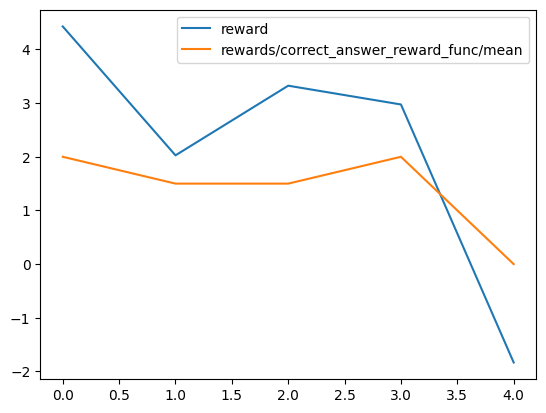

time: 6.77 s (started: 2026-07-09 09:42:33 +00:00)


In [49]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [ ]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Size this from the quick train: max_steps ≈ target_seconds / your
    # measured seconds-per-step. E.g. ~45s/step -> ~80 steps/hour. The
    # example run converged around step 400 (with vLLM); on the slower HF
    # path, expect to run 100+ steps and see clear reward growth rather
    # than full convergence within an hour.
    max_steps=100,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. s - 1 so far
4. s - 2 so far
5. t - 2 so far
6. e - 2 so far
7. n - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.001500,4.428571,0.980866,106.250000,93.000000,199.000000,0.000000,106.250000,93.000000,199.000000,0.038151,1.000000,0.000000,0.250000,1.164965,0.178571,0.828607,1.000000,0.000000,2.000000,0.000000
2,0.002300,2.708333,2.099716,81.125000,67.000000,89.000000,0.000000,81.125000,67.000000,89.000000,0.056810,0.875000,0.353553,0.000000,1.772811,-0.416667,0.417475,1.000000,0.000000,1.250000,1.035098
3,0.001700,2.850000,1.402832,83.500000,38.000000,131.000000,0.000000,83.500000,38.000000,131.000000,0.043419,0.825000,0.291548,-0.250000,2.187628,0.275000,0.549097,1.000000,0.000000,1.000000,1.069045
4,0.002200,2.029167,1.651737,58.250000,39.000000,114.000000,0.000000,58.250000,39.000000,114.000000,0.055389,0.562500,0.372012,-1.875000,1.726888,0.341667,0.743597,1.000000,0.000000,2.000000,0.000000
5,0.001100,-2.060630,1.928999,116.000000,103.000000,153.000000,0.000000,116.000000,103.000000,153.000000,0.027668,1.000000,0.000000,-3.750000,1.035098,-0.560630,0.631180,1.000000,0.000000,0.250000,0.707107
6,0.002100,3.150000,2.770766,75.875000,65.000000,115.000000,0.000000,75.875000,65.000000,115.000000,0.052908,1.000000,0.000000,0.500000,2.070197,0.150000,0.366450,1.000000,0.000000,0.500000,0.925820
7,0.002900,6.450000,0.602376,77.500000,75.000000,89.000000,0.000000,77.500000,75.000000,89.000000,0.073442,1.000000,0.000000,2.000000,0.000000,0.450000,0.602376,1.000000,0.000000,2.000000,0.000000
8,0.003100,3.854167,1.089952,57.625000,53.000000,66.000000,0.000000,57.625000,53.000000,66.000000,0.076704,0.812500,0.115728,-0.500000,1.069045,0.541667,0.395912,1.000000,0.000000,2.000000,0.000000
9,0.000500,2.083333,1.218248,91.000000,80.000000,94.000000,0.000000,91.000000,80.000000,94.000000,0.013571,0.982143,0.050508,-0.625000,1.060660,-0.273810,0.300900,1.000000,0.000000,1.000000,1.069045
10,0.001800,1.250000,1.838737,73.875000,39.000000,102.000000,0.000000,73.875000,39.000000,102.000000,0.045881,0.750000,0.377964,-2.375000,1.685018,0.625000,0.517549,1.000000,0.000000,1.250000,1.035098



--------------------
Question: How many of the letter "f" are there in the word "oath"
Answer: 0
Response: <reasoning>
Counting the number of f's in the word oath
1. o - 0 so far
2. a - 1 so far
3. t - 2 so far
4. h - 3 so far
5. e - 3 so far
There are no 'f' in the word "oath".
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    

--------------------
Question: How many of the letter "a" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of a's in the word knack
1. k - 0 so far
2. n - 1 so far
3. a - 1 (first 'a') + 1 (second 'a') = 2 so far
4. c - 2 so far
5. k - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    

--------------------
Question: How many of the letter "w" are there in the word "wisp"
Answer: 1
Response: <reasoning>
Counting the number of w's in the word wisp
1. w - 1 so far
2. i - 0 (no more w's after the first one)
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


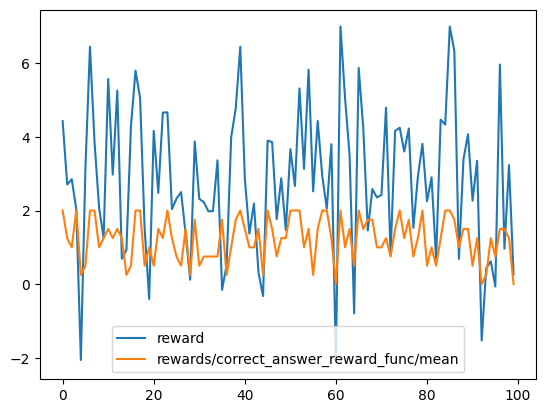

time: 146 ms (started: 2026-07-09 10:10:28 +00:00)


In [51]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [52]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
# save_lora() is unsloth's vLLM-path method; save_pretrained() is the PEFT
# equivalent and writes the same adapter weights to the same directory
model.save_pretrained("grpo_saved_lora")

time: 1.04 s (started: 2026-07-09 10:10:41 +00:00)


In [53]:
# (Modified: the trained adapter is already live on `model`, so
#  OLD = adapter disabled (base model)  — vLLM equivalent: lora_request=None
#  NEW = adapter enabled                — vLLM equivalent: load_lora(...))


def compare_old_and_new_model(messages):
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    FastLanguageModel.for_inference(model)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    # OLD: disable_adapter() zeroes out the LoRA contribution for the duration
    # of the block, giving the original base model's behavior
    with model.disable_adapter(), torch.no_grad():
        generated = model.generate(
            **inputs, max_new_tokens=1024,
            do_sample=True, temperature=0.8, top_p=0.95,
        )
    old = tokenizer.decode(
        generated[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )

    # NEW: adapter active (the GRPO-trained weights)
    with torch.no_grad():
        generated = model.generate(
            **inputs, max_new_tokens=1024,
            do_sample=True, temperature=0.8, top_p=0.95,
        )
    new = tokenizer.decode(
        generated[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )

    FastLanguageModel.for_training(model)

    print("===OLD===\n")
    print(old)
    print("\n\n===NEW===\n")
    print(new)


time: 3.02 ms (started: 2026-07-09 10:10:47 +00:00)


### Compare the old and new models on the letter-counting task

In [ ]:
# Let's try spelling the first word from the dataset

# Load the first item from the dataset (index 0) and compare the old and new models
# ds[0]["prompt"] is already the [system, user] message list built in the
# dataset cell — the same prompt format the model was trained on
compare_old_and_new_model(ds[0]["prompt"])



===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 8.17 s (started: 2026-07-09 10:10:54 +00:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [ ]:
# Let's see if the model still remembers some of the facts from its original training

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
# A general-knowledge question far from the training task: if beta's KL
# anchor did its job, OLD and NEW should both answer correctly. If NEW
# fails, training drifted too far (consider higher beta / fewer steps).
compare_old_and_new_model([
    {"role": "system", "content": ""},
    {"role": "user", "content": "What is the capital city of France?"},
])




===OLD===

The capital city of France is Paris.


===NEW===

The capital city of France is Paris.
time: 1.5 s (started: 2026-07-09 10:11:19 +00:00)


Great job! Congrats on completing the project! 🎉🤗